In [1]:
from IPython.display import Markdown, display

display(Markdown("""
**Ноутбук 5: 05_Hyperparameter_Tuning_and_Calibration.ipynb**

Ноутбук посвящён настройке гиперпараметров LightGBM и калибровке вероятностей. С помощью Optuna (50 итераций, максимизация ROC‑AUC) подобраны оптимальные параметры: n_estimators=1000, learning_rate≈0,021, num_leaves=60, scale_pos_weight≈6,95, subsample=0,80, colsample_bytree=0,75 и др. 

Обученная модель показала на тесте ROC‑AUC 0,7571. Затем выполнена калибровка вероятностей (Platt scaling) – логистическая регрессия на предсказаниях валидации. Калибровка заметно снизила Brier score с 0,125 до 0,068, не ухудшив ROC‑AUC. По калибровочной кривой на валидации подобран порог (0,1783), максимизирующий F1. На тесте калиброванная модель с новым порогом достигла F1 = 0,3034 против 0,3029 у некалиброванной. Финальная калиброванная модель, калибратор и порог сохранены. Эксперимент залогирован в MLflow.
"""))


**Ноутбук 5: 05_Hyperparameter_Tuning_and_Calibration.ipynb**

Ноутбук посвящён настройке гиперпараметров LightGBM и калибровке вероятностей. С помощью Optuna (50 итераций, максимизация ROC‑AUC) подобраны оптимальные параметры: n_estimators=1000, learning_rate≈0,021, num_leaves=60, scale_pos_weight≈6,95, subsample=0,80, colsample_bytree=0,75 и др. 

Обученная модель показала на тесте ROC‑AUC 0,7571. Затем выполнена калибровка вероятностей (Platt scaling) – логистическая регрессия на предсказаниях валидации. Калибровка заметно снизила Brier score с 0,125 до 0,068, не ухудшив ROC‑AUC. По калибровочной кривой на валидации подобран порог (0,1783), максимизирующий F1. На тесте калиброванная модель с новым порогом достигла F1 = 0,3034 против 0,3029 у некалиброванной. Финальная калиброванная модель, калибратор и порог сохранены. Эксперимент залогирован в MLflow.


In [1]:
import numpy as np
import pandas as pd
import joblib
import optuna
import mlflow
import mlflow.sklearn
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, f1_score, precision_score, recall_score, precision_recall_curve
import matplotlib.pyplot as plt

np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

Загрузка обработанных данных

In [2]:
preprocessor = joblib.load('../artifacts/preprocessor.pkl')
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')

y_train = pd.read_csv('../data/processed/y_train_lin.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val_lin.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test_lin.csv').values.ravel()

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Train: {X_train_processed.shape}, Val: {X_val_processed.shape}, Test: {X_test_processed.shape}")

Train: (215257, 168), Val: (46127, 168), Test: (46127, 168)


Настройка гиперпараметров LightGBM с Optuna

In [3]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5, 20),  # дисбаланс ~ 8%, baseline ~11.4
        'random_state': 42,
        'verbose': -1
    }
    
    model = LGBMClassifier(**params)
    model.fit(X_train_processed, y_train,
              eval_set=[(X_val_processed, y_val)],
              eval_metric='auc',
              callbacks=[optuna.integration.LightGBMPruningCallback(trial, 'auc')])
    
    y_val_proba = model.predict_proba(X_val_processed)[:, 1]
    roc_auc = roc_auc_score(y_val, y_val_proba)
    return roc_auc

In [4]:
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:")
best_trial = study.best_trial
best_params = study.best_params
print(f"ROC-AUC: {best_trial.value:.4f}")
print("Лучшие гиперпараметры:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: U

Best trial:
ROC-AUC: 0.7522
Лучшие гиперпараметры:
  n_estimators: 1000
  learning_rate: 0.02115210569911367
  num_leaves: 60
  subsample: 0.7986389946401871
  colsample_bytree: 0.7496417725535651
  reg_alpha: 2.4133218350898566
  reg_lambda: 0.0004276878612811583
  min_child_samples: 31
  scale_pos_weight: 6.948544814122348


Обучение лучшей модели

In [5]:
model_tuned = LGBMClassifier(**best_params, random_state=42, verbose=-1)
model_tuned.fit(X_train_processed, y_train)
y_val_proba_raw = model_tuned.predict_proba(X_val_processed)[:, 1]
y_test_proba_raw = model_tuned.predict_proba(X_test_processed)[:, 1]

C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\varva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Калибровка вероятностей (Platt scaling)

In [6]:
calibrator = LogisticRegression(C=1e6, solver='lbfgs')
calibrator.fit(y_val_proba_raw.reshape(-1, 1), y_val)

def calibrate(proba):
    return calibrator.predict_proba(proba.reshape(-1, 1))[:, 1]

y_val_proba_cal = calibrate(y_val_proba_raw)
y_test_proba_cal = calibrate(y_test_proba_raw)

In [7]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_cal)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])
best_threshold_val = thresholds[best_idx]
print(f"Оптимальный порог (калиброванная, по валидации): {best_threshold_val:.4f}")

Оптимальный порог (калиброванная, по валидации): 0.1783


In [8]:
y_test_pred_cal = (y_test_proba_cal >= best_threshold_val).astype(int)

In [9]:
y_test_pred_raw = (y_test_proba_raw >= 0.5).astype(int)

metrics_raw = {
    'roc_auc': roc_auc_score(y_test, y_test_proba_raw),
    'brier': brier_score_loss(y_test, y_test_proba_raw),
    'f1': f1_score(y_test, y_test_pred_raw),
    'precision': precision_score(y_test, y_test_pred_raw),
    'recall': recall_score(y_test, y_test_pred_raw)
}

metrics_cal = {
    'roc_auc': roc_auc_score(y_test, y_test_proba_cal),
    'brier': brier_score_loss(y_test, y_test_proba_cal),
    'f1': f1_score(y_test, y_test_pred_cal),
    'precision': precision_score(y_test, y_test_pred_cal),
    'recall': recall_score(y_test, y_test_pred_cal)
}

print("\nНекалиброванная модель (порог 0.5)")
for k, v in metrics_raw.items():
    print(f"{k}: {v:.4f}")

print("\nКалиброванная модель (порог {:.4f})".format(best_threshold_val))
for k, v in metrics_cal.items():
    print(f"{k}: {v:.4f}")


Некалиброванная модель (порог 0.5)
roc_auc: 0.7571
brier: 0.1250
f1: 0.3029
precision: 0.2281
recall: 0.4506

Калиброванная модель (порог 0.1783)
roc_auc: 0.7571
brier: 0.0680
f1: 0.3034
precision: 0.2583
recall: 0.3676


In [10]:
if metrics_cal['f1'] > metrics_raw['f1']:
    final_model = (model_tuned, calibrator, best_threshold_val, 'calibrated')
    print("\nВыбрана калиброванная модель с порогом {:.4f}".format(best_threshold_val))
else:
    final_model = (model_tuned, None, 0.5, 'raw')
    print("\nВыбрана некалиброванная модель (порог 0.5)")


Выбрана калиброванная модель с порогом 0.1783


In [13]:
import json

if final_model[3] == 'calibrated':
    joblib.dump(model_tuned, '../artifacts/lightgbm_tuned.pkl')
    joblib.dump(calibrator, '../artifacts/calibrator.pkl')
    with open('../artifacts/threshold.json', 'w') as f:
        json.dump({'threshold': best_threshold_val}, f)
    print("Сохранены: модель, калибратор, порог")
else:
    joblib.dump(model_tuned, '../artifacts/lightgbm_tuned.pkl')
    print("Сохранена только некалиброванная модель")

with open('../artifacts/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

Сохранены: модель, калибратор, порог


Логирование в MLflow

In [14]:
with mlflow.start_run(run_name="LightGBM_tuned_calibrated"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        'raw_roc_auc_test': metrics_raw['roc_auc'],
        'raw_brier_test': metrics_raw['brier'],
        'raw_f1_test': metrics_raw['f1'],
        'cal_roc_auc_test': metrics_cal['roc_auc'],
        'cal_brier_test': metrics_cal['brier'],
        'cal_f1_test': metrics_cal['f1'],
        'best_threshold': best_threshold_val if final_model[3]=='calibrated' else 0.5
    })
    mlflow.sklearn.log_model(model_tuned, "lightgbm_model")
print("MLflow run завершён")

2026/05/18 16:47:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 16:47:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run завершён


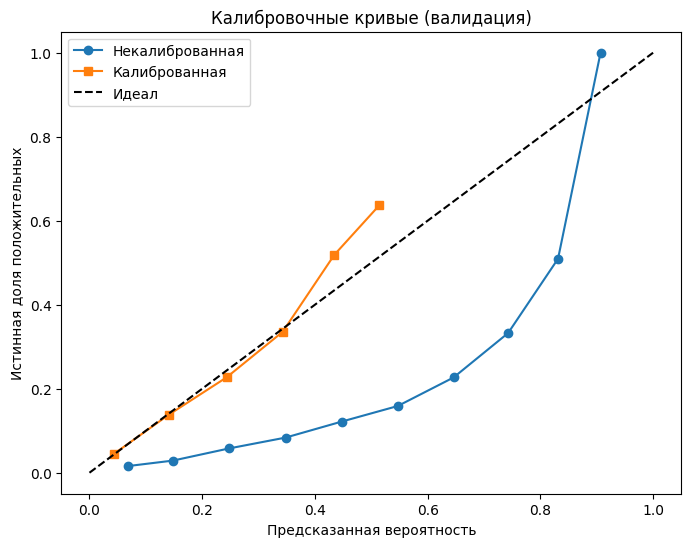

In [15]:
plt.figure(figsize=(8,6))
prob_true_raw, prob_pred_raw = calibration_curve(y_val, y_val_proba_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_val, y_val_proba_cal, n_bins=10)
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Некалиброванная')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Калиброванная')
plt.plot([0,1],[0,1], 'k--', label='Идеал')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Истинная доля положительных')
plt.title('Калибровочные кривые (валидация)')
plt.legend()
plt.savefig('../artifacts/calibration_curve.png')
plt.show()